ADF Statistic: -5.420363569360301
p-value: 3.06910808912912e-06
The data is stationary (p-value < 0.05).
ADF Statistic: -14.573485921292194
p-value: 4.588403154030422e-27
The data is stationary (p-value < 0.05).


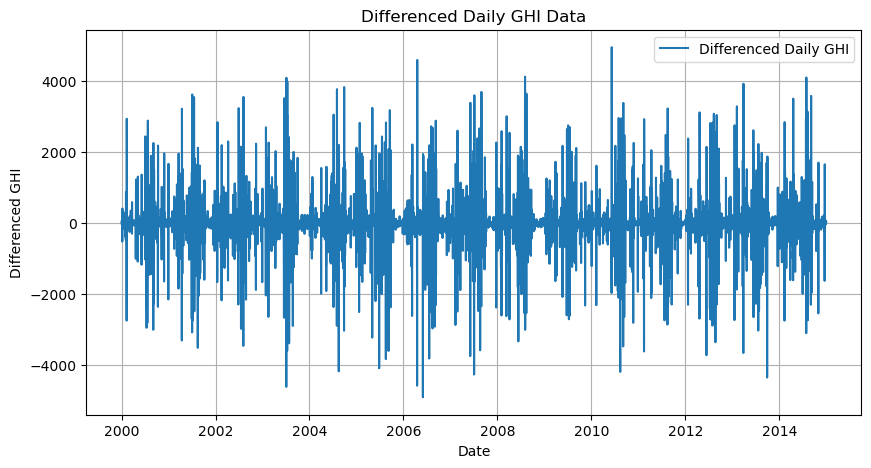

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=86746.570, Time=2.29 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=110422.853, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=103989.904, Time=0.99 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=86784.665, Time=1.23 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=86744.345, Time=1.13 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=87072.250, Time=0.90 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=86753.269, Time=3.19 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=3.76 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=87199.780, Time=0.97 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 15.020 seconds
                               SARIMAX Results                                
Dep. Variable:    

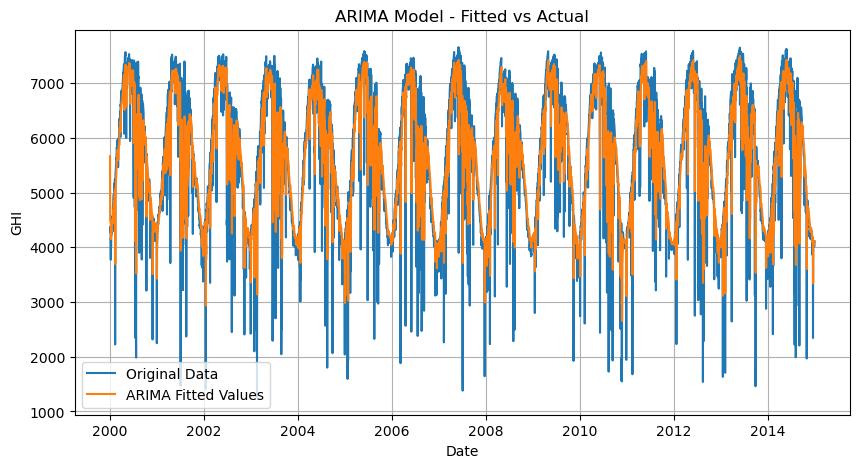

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=23.27 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=93514.671, Time=0.09 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=87670.517, Time=4.54 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=89770.332, Time=4.59 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=110422.853, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=87693.925, Time=0.27 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=87634.450, Time=13.52 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=87631.507, Time=19.81 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=87668.620, Time=8.44 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=87619.853, Time=33.13 sec


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import warnings

warnings.filterwarnings("ignore")

# Load the data
data = pd.read_csv("GHI_DailySum_R2.csv", parse_dates=['Date'], dayfirst=True)

# Check Stationarity (ADF Test)
def check_stationarity(series):
    result = adfuller(series, autolag='AIC')
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] < 0.05:
        print("The data is stationary (p-value < 0.05).")
    else:
        print("The data is not stationary (p-value >= 0.05).")

# Subset the data for daily GHI values
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)  # Ensure the date is correctly formatted
daily_ghi = data.groupby('Date')['GHI'].mean()  # You can group by 'Date' to get daily GHI if it's not already daily data

# Check stationarity of the data
check_stationarity(daily_ghi)

# Differencing if data is not stationary
daily_ghi_diff = daily_ghi.diff().dropna()
check_stationarity(daily_ghi_diff)

# Plot the differenced data
plt.figure(figsize=(10, 5))
plt.plot(daily_ghi_diff, label="Differenced Daily GHI")
plt.title("Differenced Daily GHI Data")
plt.xlabel("Date")
plt.ylabel("Differenced GHI")
plt.legend()
plt.grid()
plt.show()

# Auto ARIMA to find the best parameters
auto_model = auto_arima(daily_ghi, seasonal=False, stepwise=True, trace=True, suppress_warnings=True)
print(auto_model.summary())

# Fit ARIMA Model
arima_model = ARIMA(daily_ghi, order=auto_model.order).fit()
print(arima_model.summary())

# Plot ARIMA Predictions
plt.figure(figsize=(10, 5))
plt.plot(daily_ghi, label="Original Data")
plt.plot(arima_model.fittedvalues, label="ARIMA Fitted Values")
plt.title("ARIMA Model - Fitted vs Actual")
plt.xlabel("Date")
plt.ylabel("GHI")
plt.legend()
plt.grid()
plt.show()

# Seasonal Auto ARIMA for SARIMA
seasonal_model = auto_arima(daily_ghi, seasonal=True, m=12, stepwise=True, trace=True, suppress_warnings=True)
print(seasonal_model.summary())

# Fit SARIMA Model
sarima_model = SARIMAX(daily_ghi, order=seasonal_model.order, seasonal_order=seasonal_model.seasonal_order).fit()
print(sarima_model.summary())

# Plot SARIMA Predictions
sarima_pred = sarima_model.get_prediction(start=pd.to_datetime("2022-01-01"), end=pd.to_datetime("2023-12-31"))
sarima_conf_int = sarima_pred.conf_int()

plt.figure(figsize=(10, 5))
plt.plot(daily_ghi, label="Original Data")
plt.plot(sarima_pred.predicted_mean, label="SARIMA Predictions")
plt.fill_between(sarima_conf_int.index, sarima_conf_int.iloc[:, 0], sarima_conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title("SARIMA Model - Forecast and Confidence Intervals")
plt.xlabel("Date")
plt.ylabel("GHI")
plt.legend()
plt.grid()
plt.show()
